<a href="https://colab.research.google.com/github/krishRajawat/My-Google-Colab-Work/blob/main/CSI_%26_Fraud_Detection_by_Krish.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


Dataset Distribution:
label
0    86.593683
1    13.406317
Name: proportion, dtype: float64

--- Cost-Sensitive Model Performance ---
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       966
           1       0.93      0.93      0.93       149

    accuracy                           0.98      1115
   macro avg       0.96      0.96      0.96      1115
weighted avg       0.98      0.98      0.98      1115



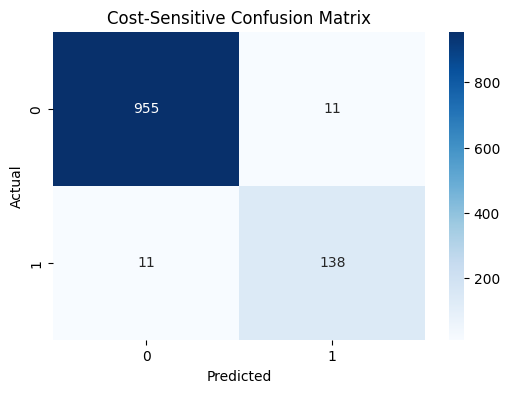

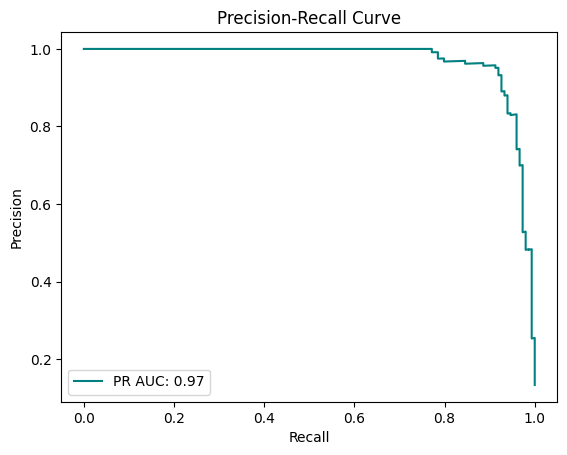

In [ ]:
# "Cost-Sensitive Intelligent Spam & Fraud Detection System"
# Author: Krish Rajawat
import pandas as pd
import numpy as np
import re
import nltk
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns

# 1. DOWNLOAD DATASET
url = "https://raw.githubusercontent.com/justmarkham/pycon-2016-tutorial/master/data/sms.tsv"
df = pd.read_csv(url, sep='\t', header=None, names=['label', 'message'])

# 2. PRE-PROCESSING (NLP)
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower() # Lowercase
    text = re.sub(r'[^a-z0-9\s]', '', text) # Remove special chars
    words = text.split()
    words = [w for w in words if w not in stop_words] # Remove stopwords
    return " ".join(words)

df['message'] = df['message'].apply(clean_text)
df['label'] = df['label'].map({'ham': 0, 'spam': 1})

# Check Imbalance
print(f"Dataset Distribution:\n{df['label'].value_counts(normalize=True) * 100}")

# 3. VECTORIZATION
tfidf = TfidfVectorizer(max_features=3000)
X = tfidf.fit_transform(df['message']).toarray()
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. COST-SENSITIVE MODELING
# I assigned a weight of 5 to Spam (Class 1) and 1 to Ham (Class 0)
# This tells the model "Missing a spam is 5x more costly than misclassifying ham"
cost_sensitive_model = LogisticRegression(class_weight={0: 1, 1: 5})
cost_sensitive_model.fit(X_train, y_train)

# 5. EVALUATION
y_pred = cost_sensitive_model.predict(X_test)
print("\n--- Cost-Sensitive Model Performance ---")
print(classification_report(y_test, y_pred))

# 6. VISUALIZATION (Confusion Matrix)
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Cost-Sensitive Confusion Matrix')
plt.show()

# 7. PRECISION RECALL CURVE
precision, recall, thresholds = precision_recall_curve(y_test, cost_sensitive_model.predict_proba(X_test)[:,1])
plt.plot(recall, precision, color='teal', label=f'PR AUC: {auc(recall, precision):.2f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()